In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.model_selection import train_test_split


In [14]:
df = pd.read_csv('Final_Project_export/data2.txt', header=None, names=['x', 'y'])
x = df['x'].values
y = df['y'].values

In [ ]:
# *p 表示接受任意多个参数，这样我们可以用同一个函数处理不同的 degree
def poly_model(x, *p):
    # np.polyval 计算多项式的值: p[0]*x^n + p[1]*x^(n-1) + ...
    return np.polyval(p, x)

degrees = range(1, 10)
mse_list = []
models = {} # 存一下模型，方便后面画图用

# 循环 1 到 9 次，计算每个degree的模型
for deg in degrees:
    # 初始猜测值 (Initial guess)
    # deg次多项式有 deg+1 个系数。我们全猜 1.0
    p0 = [1.0] * (deg + 1)
    
    # 使用 curve_fit 算系数
    # poly_model 是我们的函数，x, y 是数据，p0 决定了参数个数
    popt, pcov = curve_fit(poly_model, x, y, p0=p0)
    
    # 把这个训练好的模型存起来
    # lambda 表达式创建一个可以直接调用的函数
    models[deg] = lambda x_val, p=popt: poly_model(x_val, *p)
    
    # 算一下误差 MSE
    y_pred = poly_model(x, *popt)
    mse = np.mean((y - y_pred)**2)
    mse_list.append(mse)

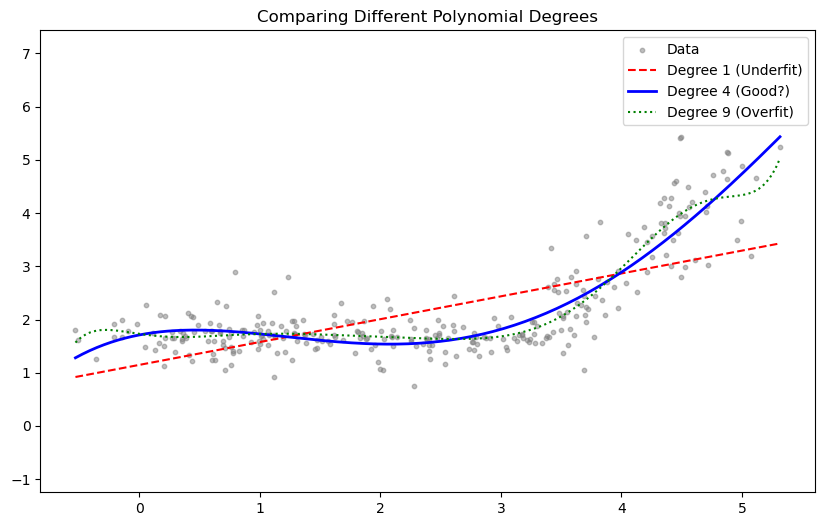

In [16]:
# ---------------------------------------------------------
# 3. 可视化对比 (Task 2 & Fig 1)
# ---------------------------------------------------------
# 我们挑几个典型的 degree 画在图上，比如 1, 4, 9

x_line = np.linspace(min(x), max(x), 200)

plt.figure(figsize=(10, 6))
plt.scatter(x, y, s=10, color='gray', alpha=0.5, label='Data')

# 画出 Degree 1, 4, 9 的曲线
plt.plot(x_line, models[1](x_line), 'r--', label='Degree 1 (Underfit)')
plt.plot(x_line, models[4](x_line), 'b-', linewidth=2, label='Degree 4 (Good?)')
plt.plot(x_line, models[9](x_line), 'g:', label='Degree 9 (Overfit)')

plt.title('Comparing Different Polynomial Degrees')
plt.legend()
plt.ylim(min(y)-2, max(y)+2) 
plt.show()

Degree     | MSE       
-------------------------
1          | 0.46275
2          | 0.22693
3          | 0.19236
4          | 0.18817
5          | 0.17174
6          | 0.16994
7          | 0.16780
8          | 0.16621
9          | 0.16485


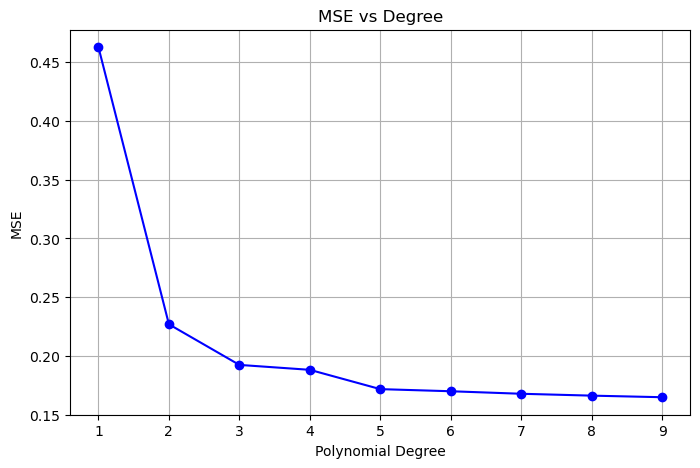

In [17]:
# ---------------------------------------------------------
# 4. 验证与表格 (Verification & Fig 2)
# ---------------------------------------------------------
# 打印 MSE 表格
print(f"{'Degree':<10} | {'MSE':<10}")
print("-"*25)
for i in range(len(degrees)):
    print(f"{degrees[i]:<10} | {mse_list[i]:.5f}")

# 画 MSE 图
plt.figure(figsize=(8, 5))
plt.plot(degrees, mse_list, 'bo-')
plt.xlabel('Polynomial Degree')
plt.ylabel('MSE')
plt.title('MSE vs Degree')
plt.grid(True)
plt.show()

Degree     | Train MSE    | Test MSE    
----------------------------------------
1          | 0.45657      | 0.49310
2          | 0.21284      | 0.28482
3          | 0.17267      | 0.27589
4          | 0.17066      | 0.26374
5          | 0.15544      | 0.24015
6          | 0.15283      | 0.24217
7          | 0.14860      | 0.24851
8          | 0.14517      | 0.25486
9          | 0.14444      | 0.25154


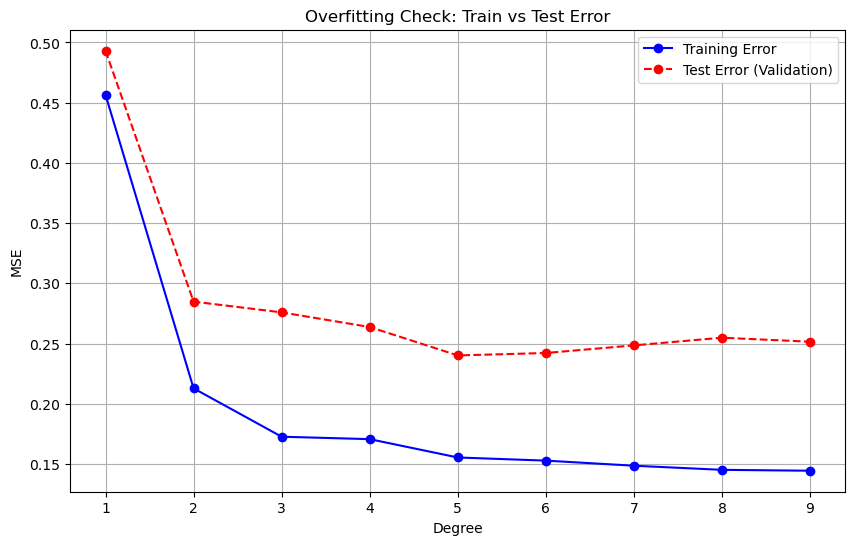

In [18]:
# ---------------------------------------------------------
# 5. 过拟合检测 (Overfitting Check)
# ---------------------------------------------------------
# 解释：
# 为了看模型有没有死记硬背(Overfitting)，我们把数据拆成两份：
# 1. 训练集 (Train): 用来算参数
# 2. 测试集 (Test): 用来考试，看它对没见过的数据表现怎么样

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

train_errors = []
test_errors = []

print(f"{'Degree':<10} | {'Train MSE':<12} | {'Test MSE':<12}")
print("-" * 40)

for deg in degrees:
    p0 = [1.0] * (deg + 1)
    
    # 注意：只用 x_train, y_train 来拟合！
    popt, _ = curve_fit(poly_model, x_train, y_train, p0=p0)
    
    # 1. 看看在训练集上的表现 (Training Error)
    y_train_pred = poly_model(x_train, *popt)
    train_mse = np.mean((y_train - y_train_pred)**2)
    
    # 2. 看看在测试集上的表现 (Test Error)
    y_test_pred = poly_model(x_test, *popt)
    test_mse = np.mean((y_test - y_test_pred)**2)
    
    train_errors.append(train_mse)
    test_errors.append(test_mse)
    
    print(f"{deg:<10} | {train_mse:.5f}      | {test_mse:.5f}")

# 画图对比
plt.figure(figsize=(10, 6))
plt.plot(degrees, train_errors, 'b-o', label='Training Error')
plt.plot(degrees, test_errors, 'r--o', label='Test Error (Validation)')
plt.xlabel('Degree')
plt.ylabel('MSE')
plt.title('Overfitting Check: Train vs Test Error')
plt.legend()
plt.grid(True)
plt.show()